## Importing the neccsessary libraries

In [25]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error, root_mean_squared_error,r2_score
from sklearn.ensemble import RandomForestRegressor

# Loadind the dataset

In [26]:
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


# Rows and Columns

In [27]:
print("Shape of Dataset : ",df.shape)

Shape of Dataset :  (545, 13)


# Features and Target 

In [28]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [29]:
target = "price"

features = [col for col in df.columns if col != "price"]

print("Target : ", target)
print("Features : ",features)

Target :  price
Features :  ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


# Checking for Missing values

In [30]:
print("Missing Values : ")
print(df.isnull().sum())

Missing Values : 
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# Duplicate Row Check 

In [32]:
print("Duplicated Rows : ",df.duplicated().sum())

Duplicated Rows :  0


# Identifying Categorical Columns

In [33]:
categorical_columns = df.select_dtypes(include=["object"]).columns
print(categorical_columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


# One-Hot Enconding

In [34]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [35]:
df_encoded.shape

(545, 14)

In [36]:
print("Final Dataset Shape : ", df_encoded.shape)

Final Dataset Shape :  (545, 14)


In [37]:
# After preprocessing:
# - No missing values were found.
# - Duplicate rows were removed (if any).
# - Categorical variables were converted into numerical form using one-hot encoding.
# - Dataset is now ready for machine learning models.

In [38]:
X = df_encoded.drop("price",axis=1)
y = df_encoded["price"]

print("Features Shape : ", X.shape)
print("Target Shape : ",y.shape)

Features Shape :  (545, 13)
Target Shape :  (545,)


# Train Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

print("Training Data : ",X_train.shape)
print("Testing Data : ",X_test.shape)

Training Data :  (436, 13)
Testing Data :  (109, 13)


# Linear Regression Model

In [40]:
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
y_prediction_lr = lr_model.predict(X_test)

# Evalutaion Metrices

In [42]:
mae_lr = mean_absolute_error(y_test,y_prediction_lr)

rmse_lr = root_mean_squared_error(y_test,y_prediction_lr)

r2_lr = r2_score(y_test,y_prediction_lr)

print("Linear Regression Results ")
print("MAE : ",mae_lr)
print("RMSE : ",rmse_lr)
print("R2 Score : ",r2_lr)

Linear Regression Results 
MAE :  970043.4039201637
RMSE :  1324506.9600914388
R2 Score :  0.6529242642153184


# Random Forest Model

In [43]:
rf_model = RandomForestRegressor(
    n_estimators=100 ,
    random_state=42
)

rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# Predictions

In [44]:
y_prediction_rf = rf_model.predict(X_test)

# Evalutaion Metrices

In [45]:
mae_rf = mean_absolute_error(y_test , y_prediction_rf)

rmse_rf = root_mean_squared_error(y_test,y_prediction_rf)

r2_rf = r2_score(y_test,y_prediction_rf)

print("Random Forest Results")
print("MAE : ",mae_rf)
print("RMSE : ",rmse_rf)
print("R2 Score : ",r2_rf)

Random Forest Results
MAE :  1021546.0353211008
RMSE :  1400565.9728553821
R2 Score :  0.611918531405699


# Comparring the Models

In [46]:
print("\n Model Comparison")

print(f"Linear Regression R2 : {r2_lr : 4f}")
print(f"Random Forest R2 : {r2_rf:4f}")


 Model Comparison
Linear Regression R2 :  0.652924
Random Forest R2 : 0.611919


## Model Comparison

Linear Regression achieved an R2 score of 0.653, while Random Forest achieved an R2 score of 0.612.

Therefore, Linear Regression performed better on this dataset and was selected as the better model for house price prediction.

# House Price Distribution Histogram 

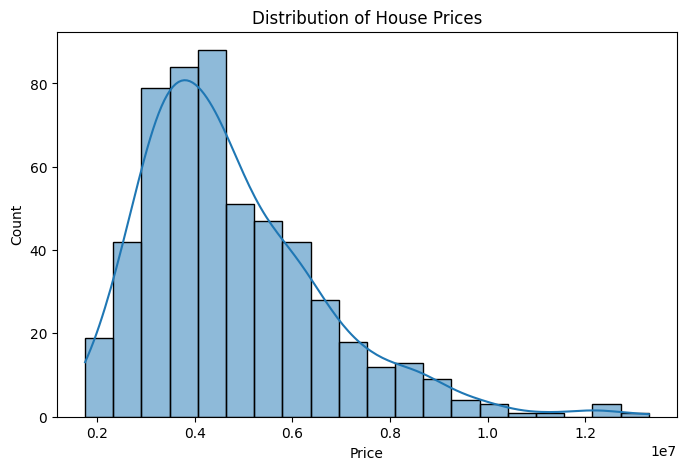

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=20 , kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("./charts/price_distribution_histogram.png",bbox_inches = "tight")
plt.show()

# Correlation Heatmap

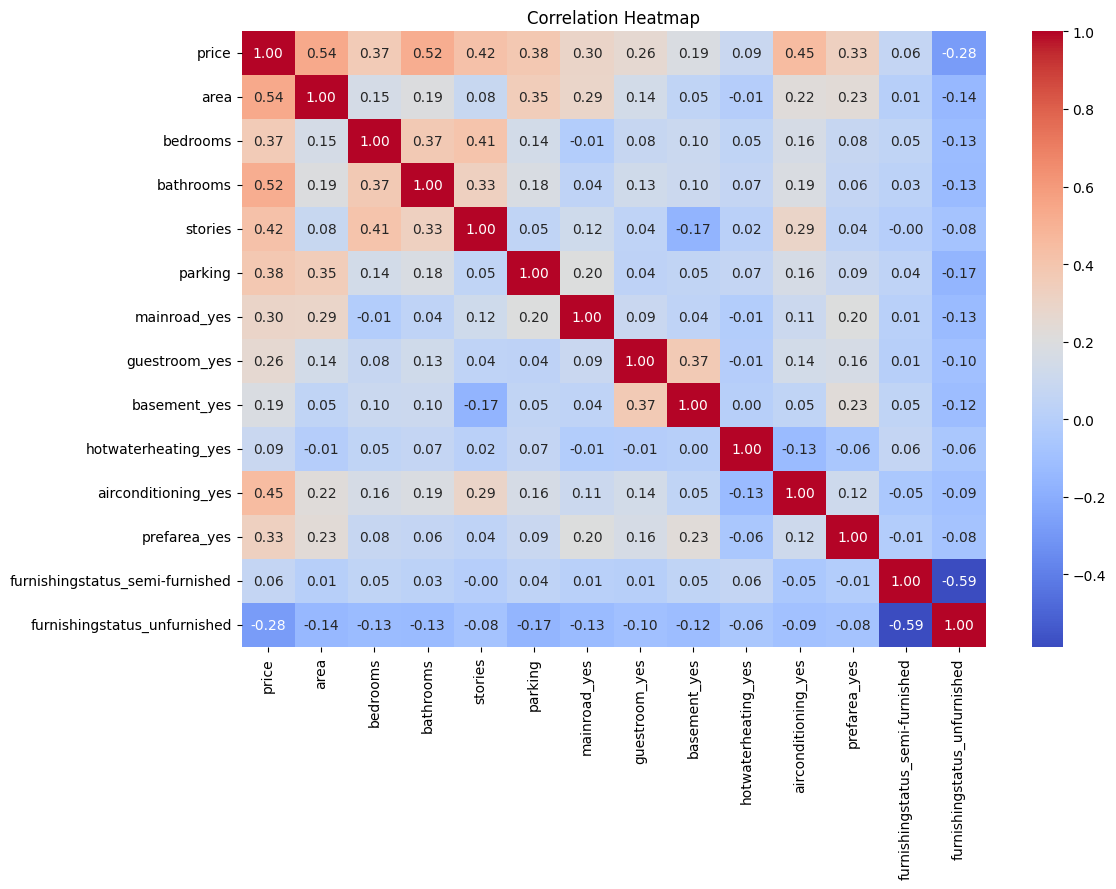

In [50]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr() ,
    annot=True ,
    cmap="coolwarm" ,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("./charts/correlation_heatmap.png", bbox_inches = "tight")

# Actual Vs Predicted Scatter Plot 

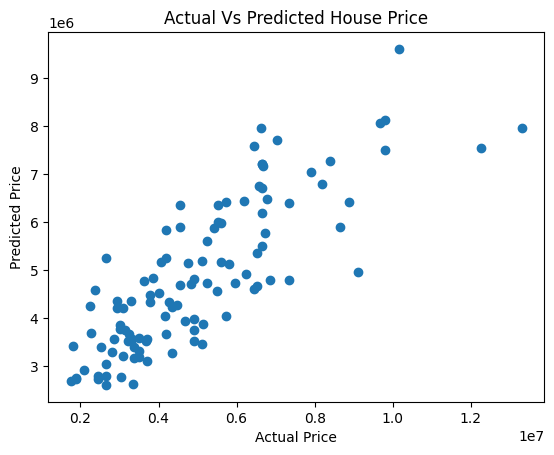

In [51]:
plt.Figure(figsize=(8,5))

plt.scatter(y_test,y_prediction_lr)

plt.title("Actual Vs Predicted House Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.savefig("./charts/actual_vs_predicted_prices.png",bbox_inches = "tight")
plt.show()

# Final Conclusion 

From the analysis, I found that factors like area, number of bathrooms, stories, and some additional facilities have a noticeable impact on house prices. The correlation heatmap helped in identifying which features were more closely related to price. The Linear Regression model achieved an R² score of around 0.65, which means it was able to make reasonably good predictions. One thing that surprised me was that Linear Regression performed better than Random Forest on this dataset. I expected the Random Forest model to give better results. Based on these findings, I would recommend that real estate businesses focus more on highlighting property size and important amenities while marketing houses, as these factors seem to influence prices the most.